# S&P 500 Derin Ogrenme ile Zaman Serisi Siniflandirma (Ham Veri Seti)

Bu notebook, S&P 500 ile iliskili hisse ve emtia verilerini makro olaylar etrafinda analiz ederek,
**T+5 gun sonra fiyatin yukselip yukselmeyecegini** tahmin eden bir **Ikili Siniflandirma (Binary Classification)** modeli kurar.

---
## Veri Seti Ozellikleri

- **Dosya:** `sp500_olay_calismasi_ham_veri.csv`
- **Satir sayisi:** ~17.520
- **Hisse/enstruman sayisi:** 11
- **Olay sayisi:** 5 (makro olaylar)
- **Tarih araligi:** 2015-11-16 -> 2025-01-29
- **Ozellikler:**
  - `Log_Getiri` — Logaritmik getiri
  - `Volatilite_10g` — 10 gunluk volatilite
  - `Volatilite_30g` — 30 gunluk volatilite
  - `Log_Hacim` — Logaritmik hacim
  - `Hacim_Degisimi` — Hacim degisimi
  - `RSI_14` — 14 gunluk RSI
  - `SMA_Uzaklik_20` — 20 gunluk SMA'dan uzaklik

**Model Mimarisi (Temel):**
```
Input (7,)
  -> Dense (64, ReLU) -> Dropout (0.5)
  -> Dense (32, ReLU) -> Dropout (0.5)
  -> Dense (1, Sigmoid)
```

**Framework:** TensorFlow / Keras

---
## Kutuphane Yuklemesi

In [1]:
# ============================================================
# Temel Kutuphaneler
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Sklearn - On Isleme
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# TensorFlow / Keras - Derin Ogrenme
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.optimizers import AdamW

# Tekrarlanabilirlik icin rastgelelik tohumunu sabitle
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow Surumu: {tf.__version__}")
print(f"NumPy Surumu: {np.__version__}")
print(f"Pandas Surumu: {pd.__version__}")
print("\nTum kutuphaneler basariyla yuklendi!")
print()

TensorFlow Surumu: 2.20.0
NumPy Surumu: 2.0.2
Pandas Surumu: 2.3.1

Tum kutuphaneler basariyla yuklendi!



---
## Adim 1: Veriyi Okuma ve Hedef Degisken (Y) Olusturma

**Mantik:**
Her `[Olay_Ismi, Hisse]` grubu icinde, kapanis fiyatini 5 gun ileri kaydirarak (`shift(-5)`) T+5 gun sonraki fiyati buluyoruz.
- T+5 fiyati > Bugunku fiyat -> **Hedef = 1 (Yukselis)**
- T+5 fiyati <= Bugunku fiyat -> **Hedef = 0 (Dusus)**

In [2]:
# ============================================================
# 1.1 - CSV Dosyasini Oku
# ============================================================
DOSYA_YOLU = "sp500_olay_calismasi_ham_veri.csv"

df = pd.read_csv(DOSYA_YOLU)

print(f"Veri Seti Boyutu: {df.shape[0]:,} satir x {df.shape[1]} sutun")
print(f"\nSutunlar:\n{list(df.columns)}")
print(f"\nHisse sayisi: {df['Hisse'].nunique()}")
print(f"Hisseler: {df['Hisse'].unique()}")
print(f"\nOlay sayisi: {df['Olay_Ismi'].nunique()}")
print(f"Olaylar: {df['Olay_Ismi'].unique()}")
print(f"\nTarih araligi: {df['Tarih'].min()} -> {df['Tarih'].max()}")
df.head()

Veri Seti Boyutu: 17,520 satir x 13 sutun

Sutunlar:
['Tarih', 'Olay_Ismi', 'Hisse', 'Grup', 'T0_Goreceli_Gun', 'Duzeltilmis_Kapanis', 'Log_Getiri', 'Volatilite_10g', 'Volatilite_30g', 'Log_Hacim', 'Hacim_Degisimi', 'RSI_14', 'SMA_Uzaklik_20']

Hisse sayisi: 11
Hisseler: ['CL=F' 'GLD' 'ITA' 'SPY' 'XLE' 'XLF' 'XLK' 'XLP' 'XLRE' 'XLV' 'XLY']

Olay sayisi: 5
Olaylar: ['ABD_Secimleri_2016' 'ABD_Secimleri_2024' 'COVID19_Pandemisi_2020'
 'Israil_Iran_2024' 'Rusya_Ukrayna_Savasi_2022']

Tarih araligi: 2015-11-16 -> 2025-01-29


,Tarih,Olay_Ismi,Hisse,Grup,T0_Goreceli_Gun,Duzeltilmis_Kapanis,Log_Getiri,Volatilite_10g,Volatilite_30g,Log_Hacim,Hacim_Degisimi,RSI_14,SMA_Uzaklik_20
0,2015-11-16,ABD_Secimleri_2016,CL=F,Emtia_Makro,-358,41.740002,0.024249,0.024750,0.025493,13.190358,0.112886,37.6284,-0.063695
1,2015-11-17,ABD_Secimleri_2016,CL=F,Emtia_Makro,-357,40.669998,-0.025969,0.018598,0.023880,12.804126,-0.320388,34.4149,-0.082676
2,2015-11-18,ABD_Secimleri_2016,CL=F,Emtia_Makro,-356,40.750000,0.001965,0.018342,0.023859,12.435274,-0.308473,34.8628,-0.076236
3,2015-11-19,ABD_Secimleri_2016,CL=F,Emtia_Makro,-355,40.540001,-0.005167,0.017990,0.022716,11.785674,-0.477747,34.2025,-0.075927
4,2015-11-20,ABD_Secimleri_2016,CL=F,Emtia_Makro,-354,40.389999,-0.003707,0.017786,0.022635,12.977668,2.293660,33.7113,-0.074908


In [3]:
# ============================================================
# 1.2 - Hedef Degisken (Y) Olusturma
# ============================================================
df = df.sort_values(by=['Olay_Ismi', 'Hisse', 'T0_Goreceli_Gun']).reset_index(drop=True)

df['Fiyat_T5'] = df.groupby(['Olay_Ismi', 'Hisse'])['Duzeltilmis_Kapanis'].shift(-5)

# Hedef degiskeni olustur: 1 = Yukselis, 0 = Dusus
df['Hedef'] = (df['Fiyat_T5'] > df['Duzeltilmis_Kapanis']).astype(int)

# T+5 hesaplanamayan (NaN) satirlari sil
satirlar_once = len(df)
df = df.dropna(subset=['Fiyat_T5']).reset_index(drop=True)
satirlar_sonra = len(df)

print(f"Silinen NaN satir sayisi: {satirlar_once - satirlar_sonra:,}")
print(f"Kalan satir sayisi: {satirlar_sonra:,}")
print(f"\nHedef Degisken Dagilimi:")
print(df['Hedef'].value_counts())
print(f"\nYukselis Orani: %{df['Hedef'].mean()*100:.2f}")

Silinen NaN satir sayisi: 275
Kalan satir sayisi: 17,245

Hedef Degisken Dagilimi:
Hedef
1    9936
0    7309
Name: count, dtype: int64

Yukselis Orani: %57.62


---
## Adim 2: Ozellik Secimi ve 2D Veri Hazirligi

**Yaklasim:**
Kayan pencere (sliding window) veya 3 boyutlu veri hazirligi **KULLANILMIYOR**.
Veri dogrudan `(Orneklem Sayisi, Ozellik Sayisi)` boyutunda standart 2D olarak hazirlaniyor.
Her satir bagimsiz bir orneklem olarak modele veriliyor.

In [7]:
# ============================================================
# 2.1 - Ozellik Sutunlarini Sec
# ============================================================
OZELLIK_SUTUNLARI = [
    'Log_Getiri',
    'Volatilite_10g',
    'Volatilite_30g',
    'Log_Hacim',
    'Hacim_Degisimi',
    'RSI_14',
    'SMA_Uzaklik_20'
]

print(f"Kullanilacak Ozellik Sayisi: {len(OZELLIK_SUTUNLARI)}")
print(f"Ozellikler: {OZELLIK_SUTUNLARI}")

# Sonsuz (inf) degerleri NaN'a cevir, sonra hem NaN hem inf satirlarini temizle
df[OZELLIK_SUTUNLARI] = df[OZELLIK_SUTUNLARI].replace([np.inf, -np.inf], np.nan)

# Eksik/sonsuz deger kontrolu
eksik = df[OZELLIK_SUTUNLARI].isnull().sum()
if eksik.sum() > 0:
    print(f"\nOzelliklerdeki Eksik/Sonsuz Degerler:\n{eksik[eksik > 0]}")
    df = df.dropna(subset=OZELLIK_SUTUNLARI).reset_index(drop=True)
    print(f"Temizleme sonrasi kalan satir: {len(df):,}")
else:
    print(f"\nHic eksik veya sonsuz deger yok!")
    print(f"Toplam satir: {len(df):,}")

Kullanilacak Ozellik Sayisi: 7
Ozellikler: ['Log_Getiri', 'Volatilite_10g', 'Volatilite_30g', 'Log_Hacim', 'Hacim_Degisimi', 'RSI_14', 'SMA_Uzaklik_20']

Ozelliklerdeki Eksik/Sonsuz Degerler:
Hacim_Degisimi    3
dtype: int64
Temizleme sonrasi kalan satir: 17,242


In [8]:
# ============================================================
# 2.2 - 2D Veri Hazirligi (Orneklem, Ozellik)
# ============================================================
# Kayan pencere veya 3D donusum YOK.
# Her satir dogrudan bir orneklem olarak kullaniliyor.

X = df[OZELLIK_SUTUNLARI].values
y = df['Hedef'].values

ozellik_sayisi = X.shape[1]

print(f"X boyutu: {X.shape}  -> (Orneklem, Ozellik)")
print(f"y boyutu: {y.shape}  -> (Orneklem,)")
print(f"\nToplam orneklem sayisi: {X.shape[0]:,}")
print(f"Ozellik sayisi: {ozellik_sayisi}")

X boyutu: (17242, 7)  -> (Orneklem, Ozellik)
y boyutu: (17242,)  -> (Orneklem,)

Toplam orneklem sayisi: 17,242
Ozellik sayisi: 7


---
## Adim 3: Train/Test Ayrimi ve Olceklendirme (Leakage-Safe)

**Veri Sizintisini (Data Leakage) Onleme:**
- `train_test_split` ile `shuffle=False` kullaniliyor (zaman serisi sirasi korunuyor)
- `StandardScaler` sadece egitim setine `fit` ediliyor
- Ardindan hem egitim hem test setine `transform` uygulaniyor

In [9]:
# ============================================================
# 3.1 - Train / Test Bolmesi (shuffle=False) + Leakage-safe Scaling
# ============================================================
# Zaman serisi oldugu icin shuffle YAPILMIYOR!
# Gecmis veri ile egitip, gelecek veri ile test ediyoruz.

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, shuffle=False
)

print(f"Bolme oncesi X boyutu: {X.shape}")
print(f"\nEgitim Seti:  X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Test Seti:    X_test={X_test.shape},  y_test={y_test.shape}")

# --- Leakage-safe olceklendirme ---
# StandardScaler SADECE egitim setine fit ediliyor
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)   # fit + transform (sadece train)
X_test  = scaler.transform(X_test)        # sadece transform (test)

print(f"\nEgitim Setindeki Yukselis Orani: %{y_train.mean()*100:.2f}")
print(f"Test Setindeki Yukselis Orani:   %{y_test.mean()*100:.2f}")
print(f"\nScaler fit edildi (sadece train): mean={scaler.mean_.round(3)}")

Bolme oncesi X boyutu: (17242, 7)

Egitim Seti:  X_train=(13793, 7), y_train=(13793,)
Test Seti:    X_test=(3449, 7),  y_test=(3449,)

Egitim Setindeki Yukselis Orani: %57.83
Test Setindeki Yukselis Orani:   %56.80

Scaler fit edildi (sadece train): mean=[0.0000e+00 1.1000e-02 1.2000e-02 1.5749e+01 1.2000e-01 5.4444e+01
 4.0000e-03]


---
## Adim 4: Feedforward (Dense) Model Mimarisi

**Mimari:**
```
Input (7,)
  -> Dense (64, ReLU) -> Dropout (0.5)
  -> Dense (32, ReLU) -> Dropout (0.5)
  -> Dense (1, Sigmoid)
```

**Neden bu mimari?**
- **Kucuk model:** 17.520 satir (T+5 shift sonrasi ~17.465) veri icin kompakt bir mimari yeterli. Bu kadar az veride derin/genis mimariler overfitting yapar.
- **Dropout(0.5):** Agresif regularizasyon, az veride ezberlemeyi engeller.
- **ReLU:** Hizli, basit, standart.

In [10]:
# ============================================================
# 4.1 - Modeli Kur
# ============================================================
model = Sequential([
    Input(shape=(ozellik_sayisi,)),

    # 1. Gizli Katman: 64 noron, ReLU aktivasyonu
    Dense(64, activation='relu'),
    Dropout(0.5),                      # Overfitting'i onlemek icin

    # 2. Gizli Katman: 32 noron, ReLU aktivasyonu
    Dense(32, activation='relu'),
    Dropout(0.5),

    # Cikti Katmani: 1 noron, Sigmoid aktivasyonu
    # 0-1 arasi olasilik uretir (Ikili siniflandirma)
    Dense(1, activation='sigmoid')
])

# Model ozetini goster
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,625 (10.25 KB)

 Trainable params: 2,625 (10.25 KB)

 Non-trainable params: 0 (0.00 B)

---
## Adim 5: Modeli Derleme ve Egitme (Compile & Fit)

**Derleme Ayarlari:**
- `loss='binary_crossentropy'`: Ikili siniflandirma icin standart kayip fonksiyonu
- `optimizer=Adam(learning_rate=0.001)`: Genel amacli optimizer
- `metrics=['accuracy']`: Dogruluk metrigi

**Egitim Ayarlari:**
- `batch_size=64`: Kucuk veri seti icin uygun
- `epochs=50`: Maksimum epoch, EarlyStopping ile erken durur
- `EarlyStopping(patience=10, restore_best_weights=True)`: Val loss 10 epoch boyunca iyilesmezse durur ve en iyi agirliklari geri yukler.

In [11]:
# ============================================================
# 5.1 - Modeli Derle (Compile)
# ============================================================
ozel_optimizer = Adam(learning_rate=0.001)

model.compile(
    loss='binary_crossentropy',       # Ikili siniflandirma kaybi
    optimizer=ozel_optimizer,          # Adam (standart)
    metrics=['accuracy']               # Dogruluk metrigi
)

print("Model derlendi.")
print(f"   Loss: binary_crossentropy")
print(f"   Optimizer: Adam(learning_rate=0.001)")
print(f"   Metrik: Accuracy")

Model derlendi.
   Loss: binary_crossentropy
   Optimizer: Adam(learning_rate=0.001)
   Metrik: Accuracy


In [12]:
# ============================================================
# 5.2 - Callback'leri Tanimla
# ============================================================
# restore_best_weights=True: Egitim bitiminde en iyi epoch'un agirliklari geri yuklenir
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

print("Callback'ler hazirlandi:")
print("   EarlyStopping(patience=10, restore_best_weights=True)")

Callback'ler hazirlandi:
   EarlyStopping(patience=10, restore_best_weights=True)


In [13]:
# ============================================================
# 5.3 - Modeli Egit (Fit)
# ============================================================
print("Model egitimi basliyor...\n")

gecmis = model.fit(
    X_train, y_train,
    validation_split=0.2,              # Egitim setinin %20'si dogrulama icin ayrilir
    epochs=50,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

print("\nEgitim tamamlandi!")

Model egitimi basliyor...

Epoch 1/50
173/173 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.5219 - loss: 0.7117 - val_accuracy: 0.5875 - val_loss: 0.6796
Epoch 2/50
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5731 - loss: 0.6911 - val_accuracy: 0.5875 - val_loss: 0.6789
Epoch 3/50
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5795 - loss: 0.6859 - val_accuracy: 0.5875 - val_loss: 0.6789
Epoch 4/50
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5829 - loss: 0.6803 - val_accuracy: 0.5875 - val_loss: 0.6782
Epoch 5/50
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5838 - loss: 0.6804 - val_accuracy: 0.5875 - val_loss: 0.6785
Epoch 6/50
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5827 - loss: 0.6798 - val_accuracy: 0.5875 - val_loss: 0.6782
Epoch 7/50
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5854 - loss: 0.6790 - val_accuracy: 0.5875 - val_loss: 0.6785
Epoch 8/50
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5867 - loss

---
## Adim 6: Model Performansini Gorsellestir ve Degerlendir

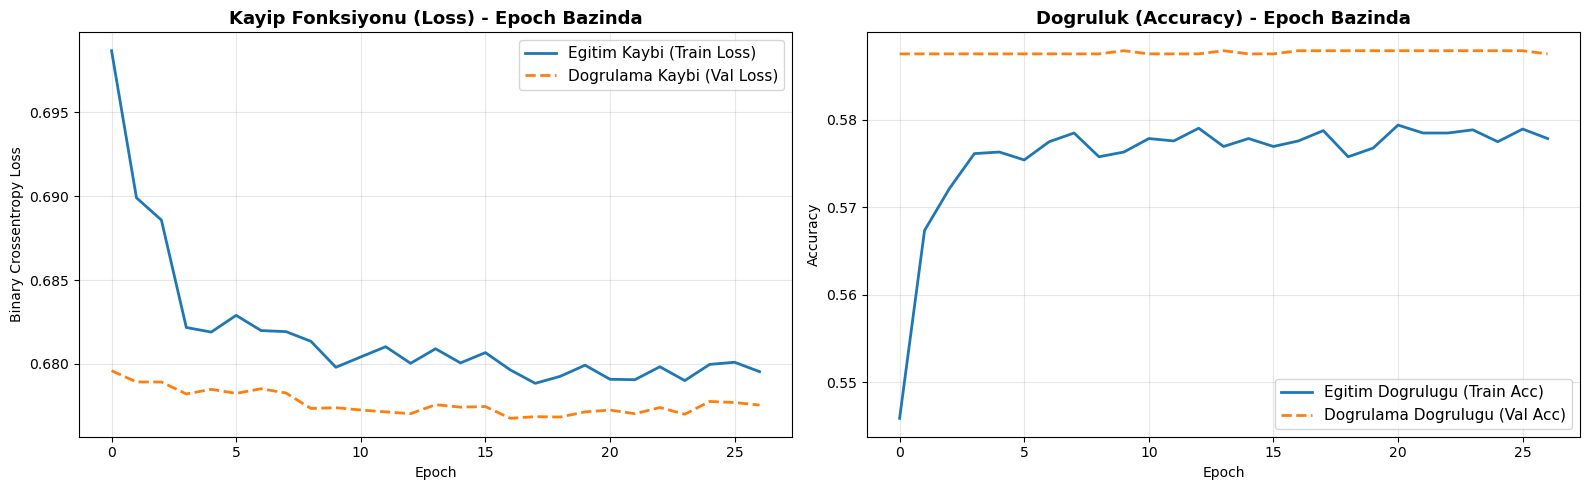


Son Epoch Istatistikleri:
   Train Loss: 0.6795
   Val Loss:   0.6775
   Fark:       0.0020
   Egitim ve dogrulama kaybi yakin -> Model dengeli ogrenmis.

En iyi epoch: 17 (Val Loss: 0.6768)
(restore_best_weights=True sayesinde modelde bu epoch'un agirliklari var)


In [14]:
# ============================================================
# 6.1 - Egitim Surecini Gorsellestir (Loss & Accuracy Grafikleri)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Sol Grafik: Loss (Kayip) ---
axes[0].plot(gecmis.history['loss'], label='Egitim Kaybi (Train Loss)', linewidth=2)
axes[0].plot(gecmis.history['val_loss'], label='Dogrulama Kaybi (Val Loss)', linewidth=2, linestyle='--')
axes[0].set_title('Kayip Fonksiyonu (Loss) - Epoch Bazinda', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary Crossentropy Loss')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# --- Sag Grafik: Accuracy (Dogruluk) ---
axes[1].plot(gecmis.history['accuracy'], label='Egitim Dogrulugu (Train Acc)', linewidth=2)
axes[1].plot(gecmis.history['val_accuracy'], label='Dogrulama Dogrulugu (Val Acc)', linewidth=2, linestyle='--')
axes[1].set_title('Dogruluk (Accuracy) - Epoch Bazinda', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('egitim_grafikleri_ham_veri.png', dpi=150, bbox_inches='tight')
plt.show()

# Overfitting tespiti icin bilgi notu
son_train_loss = gecmis.history['loss'][-1]
son_val_loss = gecmis.history['val_loss'][-1]
fark = abs(son_train_loss - son_val_loss)
print(f"\nSon Epoch Istatistikleri:")
print(f"   Train Loss: {son_train_loss:.4f}")
print(f"   Val Loss:   {son_val_loss:.4f}")
print(f"   Fark:       {fark:.4f}")
if fark > 0.1:
    print("   Egitim ve dogrulama kaybi arasinda belirgin fark var -> Overfitting riski!")
else:
    print("   Egitim ve dogrulama kaybi yakin -> Model dengeli ogrenmis.")

# En iyi epoch bilgisi
en_iyi_epoch = int(np.argmin(gecmis.history['val_loss'])) + 1
en_iyi_val_loss = min(gecmis.history['val_loss'])
print(f"\nEn iyi epoch: {en_iyi_epoch} (Val Loss: {en_iyi_val_loss:.4f})")
print("(restore_best_weights=True sayesinde modelde bu epoch'un agirliklari var)")

In [15]:
# ============================================================
# 6.2 - Test Seti Uzerinde Nihai Degerlendirme
# ============================================================

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

# Random baseline hesabi (veri setinin dengesizligine gore)
p = y_test.mean()
random_loss = -(p * np.log(max(p, 1e-10)) + (1-p) * np.log(max(1-p, 1e-10)))

print("=" * 60)
print("MODEL DEGERLENDIRME OZETI (Ham Veri Seti)")
print("=" * 60)
print(f"\n   Test Kaybi (Loss):     {test_loss:.4f}")
print(f"   Test Dogrulugu (Acc):  %{test_acc*100:.2f}")
print(f"\n   Random Baseline Loss:  {random_loss:.4f}")
print(f"   Edge (baseline-loss):  {random_loss - test_loss:+.4f}")
print(f"\n   Egitim Epoch Sayisi:   {len(gecmis.history['loss'])}")
print(f"   Ozellik Sayisi:        {ozellik_sayisi}")
print(f"   Toplam Parametre:      {model.count_params():,}")
print(f"   Mimari:                Dense(64) -> Dropout(0.5) -> Dense(32) -> Dropout(0.5) -> Dense(1)")
print(f"   Aktivasyonlar:         ReLU (gizli) / Sigmoid (cikti)")
print(f"   Regularizasyon:        Dropout(0.5) + EarlyStopping(patience=10, restore_best=True)")
print(f"   Optimizer:             Adam(learning_rate=0.001)")
print(f"   Batch Size:            64")
print("\n" + "=" * 60)
print("Analiz tamamlandi!")
print("=" * 60)

MODEL DEGERLENDIRME OZETI (Ham Veri Seti)

   Test Kaybi (Loss):     0.6838
   Test Dogrulugu (Acc):  %56.77

   Random Baseline Loss:  0.6839
   Edge (baseline-loss):  +0.0001

   Egitim Epoch Sayisi:   27
   Ozellik Sayisi:        7
   Toplam Parametre:      2,625
   Mimari:                Dense(64) -> Dropout(0.5) -> Dense(32) -> Dropout(0.5) -> Dense(1)
   Aktivasyonlar:         ReLU (gizli) / Sigmoid (cikti)
   Regularizasyon:        Dropout(0.5) + EarlyStopping(patience=10, restore_best=True)
   Optimizer:             Adam(learning_rate=0.001)
   Batch Size:            64

Analiz tamamlandi!


---
## Adim 7: Yorumlama ve Beklentiler

### Veri Seti Karsilastirmasi

| | Eski veri seti | Bu veri seti |
|---|---|---|
| Satir sayisi | ~236.000 | ~17.500 (13x az) |
| Ozellik sayisi | 9 (MACD, Bollinger) | 7 (Hacim, SMA) |
| Hisse sayisi | Cok | 11 |
| Olay sayisi | Cok | 5 |

### Bu Veri Seti Icin Beklenti

Satir sayisinin azalmasi iki farkli etki yaratir:

**Pozitif:**
- Veri daha temiz/kuratorlu olabilir (daha az farkli hisse ve olay)
- Hacim bilgisi eklendi — bu onemli bir sinyal kaynagi olabilir

**Negatif:**
- Ogrenme icin daha az ornek
- Overfitting riski artar (bu yuzden Dropout 0.5 korunuyor)
- Train/test varyansi artar (her kosuda daha fazla dalgalanma beklenir)

### Hedef Accuracy

Finansal T+5 tahminin literatur aralgi: **%54 - %58**
Bu veri setinde beklenti: **%55 - %59** (hacim sinyali bir miktar katkida bulunabilir)

### Eger sonuc memnun etmezse

Asagidaki parametrelerle oynayabilirsin (onceki tartismalardan):
- `Dropout(0.5)` -> `Dropout(0.3)` veya `Dropout(0.35)` 
- `Adam(lr=0.001)` -> `AdamW(lr=0.0005, weight_decay=0.001)` 
- `batch_size=64` -> `batch_size=128`
- `patience=10` -> `patience=15`

**Dikkat:** Bu veri seti kucuk oldugu icin daha buyuk modeller (Dense 128+) kesinlikle overfitting yapar. Kapasiteyi artirmak yerine regularizasyonla oyna.